### Agentic RAG With LangGraph

In [24]:
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()

In [25]:

import os
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

In [61]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [66]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.9)
embeddings = OpenAIEmbeddings()

In [28]:
llm

ChatOpenAI(output_version=None, client=<openai.resources.chat.completions.completions.Completions object at 0x000002D8DD00B0E0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002D8DD4FC590>, root_client=<openai.OpenAI object at 0x000002D8DCF37E00>, root_async_client=<openai.AsyncOpenAI object at 0x000002D8DD4FC2F0>, model_name='gpt-4-0613', temperature=0.9, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_proxy=None, stream_usage=True, stream_chunk_timeout=120.0)

### State Defination

In [29]:
class AgentState(TypedDict):
    question: str
    context: List[Document]
    answer: str
    needs_research: bool

In [34]:
from langchain_community.embeddings import FakeEmbeddings

### sample documents and Vector Store
Sample_text = [
    "The capital of France is Paris.",
    "The largest mammal is the blue whale.",
    "The Great Wall of China is visible from space.",
    "LangGraph is a powerful tool for building language-based applications.",
    "Agentic State Graphs are a way to model the state of an agent in a language-based application."
]
documents = [Document(page_content=text) for text in Sample_text]

# Use local fake embeddings to avoid OpenAI API quota errors
local_embeddings = FakeEmbeddings(size=1536)
vector_store = FAISS.from_documents(documents, local_embeddings)

retriever = vector_store.as_retriever()
retirver = retriever


### Agents Function

In [35]:
def decide_retrieval(state: AgentState) -> AgentState:
    question = state["question"]

    #simple heuristic: if the question contains certain keywords, we decide to retrieve
    retrieval_keywords = ["capital", "largest", "visible", "powerful", "model"]
    needs_research = any(keyword in question.lower() for keyword in retrieval_keywords)
    state["needs_research"] = needs_research
    return state

In [53]:
def genrate_answer(state: AgentState) -> AgentState:
    question = state["question"]
    documents = state.get("context", [])

    # generate a prompt for the LLM
    if documents:
        context_text = "\n".join([doc.page_content for doc in documents])
        prompt = f"Question: {question}\nContext: {context_text}\nAnswer:"
    else:
        prompt = f"Question: {question}\nAnswer:"

    # get the answer from the LLM with graceful fallback on API failures
    try:
        answer = llm.invoke(prompt).content
    except Exception as exc:
        answer = f"LLM request failed: {type(exc).__name__}. Please check API quota/key and retry."

    state["answer"] = answer
    return state

### Condition Logic

In [ ]:
def should_research(state: AgentState) -> str:
    if state["needs_research"]:
        return "RESEARCH"
    else:
        return "ANSWER"

### Build Grpah

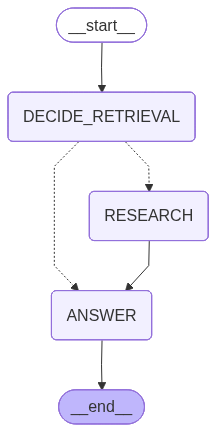

In [67]:
# create the state graph
graph = StateGraph(AgentState)

graph.add_node("DECIDE_RETRIEVAL", decide_retrieval)
graph.add_node("RESEARCH", lambda state: {"context": retriever.invoke(state["question"])})
graph.add_node("ANSWER", genrate_answer)

# set entry point
graph.set_entry_point("DECIDE_RETRIEVAL")

# route to RESEARCH only when needed, otherwise go directly to ANSWER
graph.add_conditional_edges(
    "DECIDE_RETRIEVAL",
    lambda state: "RESEARCH" if state.get("needs_research", False) else "ANSWER",
    {
        "RESEARCH": "RESEARCH",
        "ANSWER": "ANSWER",
    },
)

# linear transition after retrieval, then terminate
graph.add_edge("RESEARCH", "ANSWER")
graph.add_edge("ANSWER", END)

# compile the graph
app = graph.compile()
app

### test the Agentic System


In [64]:
def ask_question(question: str) -> str:
    initial_state = AgentState(
        question=question,
        context=[],
        answer="",
        needs_research=False
    )
    final_state = app.invoke(initial_state)
    return final_state["answer"]

In [68]:
# test the graph with a question that requires retrieval
answer = ask_question("What is the capital of France?")
print("Answer:", answer)

Answer: LLM request failed: RateLimitError. Please check API quota/key and retry.
